<a href="https://colab.research.google.com/github/brandon5254/Data_Science/blob/main/_Clasificaci%C3%B3n_de_C%C3%A1ncer_de_Mama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cargar librerias

In [ ]:
# Librerías básicas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import plotly.express as px
from sklearn.metrics import silhouette_score
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import PowerTransformer
from imblearn.over_sampling import SMOTENC
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics  import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Preprocesamiento y escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Modelos de Clustering
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# Evaluación del Clustering
from sklearn.metrics import silhouette_score, davies_bouldin_score

# Reducción de dimensionalidad (opcional para visualización)
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Cargar conjunto de datos

In [ ]:
import kagglehub
import pandas as pd

# Descargar el dataset
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

# Mostrar la ruta del dataset
print("Path to dataset files:", path)

# Cargar el archivo en un DataFrame
df = pd.read_csv(f"{path}/data.csv")  # Asegúrate de que el nombre del archivo es correcto

# Mostrar las primeras filas
df.head()




Path to dataset files: /root/.cache/kagglehub/datasets/uciml/breast-cancer-wisconsin-data/versions/2


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Analizar y visualizar el conjunto de datos


- Estadisticas (df.info(), df.describe())
- Histogramas (distribución normal)

In [ ]:
# Ver las primeras filas
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [ ]:
# Estadísticas del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


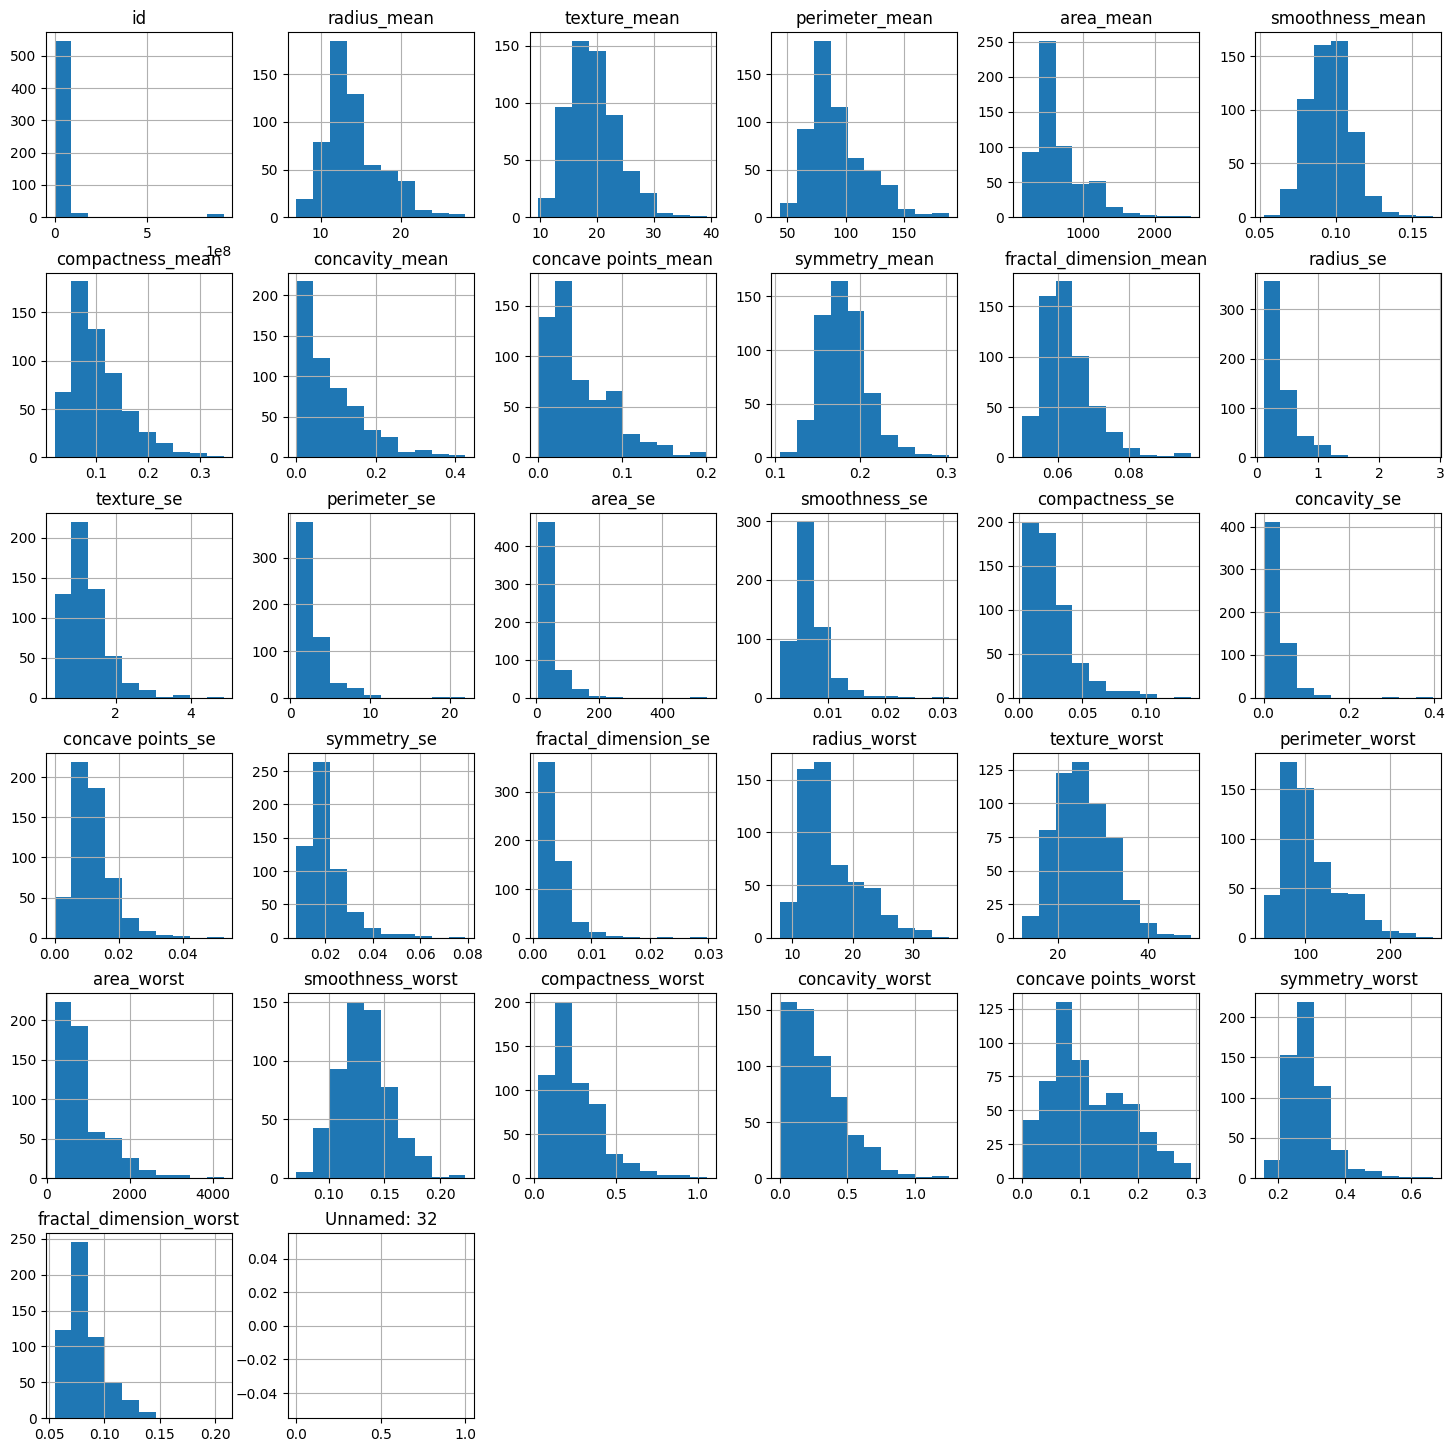

In [ ]:
# Visualizar la distribución de las variables numéricas con histogramas
df.hist(figsize=(18, 18))
plt.show()

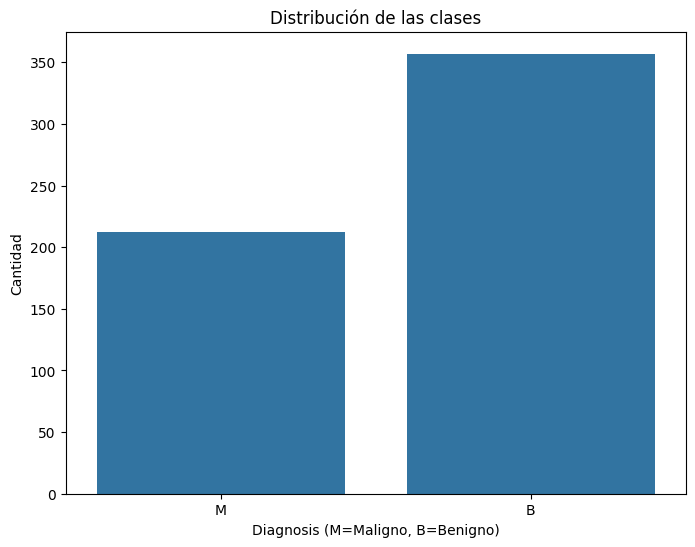

In [ ]:
# prompt: Histograma para visualizar la distribución de las clases

import matplotlib.pyplot as plt
# Histograma de la variable 'diagnosis'
plt.figure(figsize=(8, 6))
sns.countplot(x='diagnosis', data=df)
plt.title('Distribución de las clases')
plt.xlabel('Diagnosis (M=Maligno, B=Benigno)')
plt.ylabel('Cantidad')
plt.show()


# Limpiar el conjunto de datos

- Valores perdidos-nulos-anomalias
- Limpieza de datos
- Normalizar

In [ ]:
# Reemplazar las etiquetas de texto por valores numéricos (B = 0, M = 1)
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})





In [ ]:
# Verifica si hay valores nulos
df.isnull().sum()

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
# Eliminar columnas irrelevantes (por ejemplo, el ID)
df = df.drop(columns=['id'])

In [ ]:
# Eliminar columna 'Unnamed: 32' que no tiene datos
df = df.drop('Unnamed: 32', axis=1)

In [ ]:
# Separar las variables independientes (features) y la variable dependiente (target)
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [ ]:
#Es importante normalizar los datos, ya que SVM es sensible a la escala de las características:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Modelo de machine learning para clasificación

#En este caso, se ha elegido el algoritmo SVM (Support Vector Machine) para la clasificación de los tumores como benignos o malignos. Este modelo es adecuado debido a su capacidad para manejar datos complejos y su efectividad en problemas de clasificación binaria.

In [ ]:
from sklearn.svm import SVC  # Importar el clasificador SVM
svm_model = SVC(kernel='linear', random_state=42)  # Modelo SVM con kernel lineal




# Dividir el df en variables independientes y dependiente

Se identificaron las variables predictoras (features) y la variable objetivo (target) del dataset Breast Cancer Wisconsin (Diagnostic).

In [ ]:


# Separar las variables independientes (X) y la variable dependiente (y)
X = df.drop('diagnosis', axis=1)  # Eliminar la columna 'diagnosis' de X
y = df['diagnosis']  # La variable dependiente es 'diagnosis'

# Convertir la variable dependiente (diagnosis) a valores numéricos (0 = benigno, 1 = maligno)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)  # Convertir 'B' a 0 y 'M' a 1



# Particionar el conjuton de datos en datos de pueba y entrenamiento

Se utilizó train_test_split de sklearn.model_selection para dividir los datos:

70% para entrenamiento y 30% para prueba.

Esto asegura que el modelo se entrene con una parte de los datos y se evalúe con datos nuevos, simulando casos reales.

 Así se evita el sobreajuste y se garantiza una evaluación objetiva.

In [ ]:
from sklearn.model_selection import train_test_split

# Dividir el conjunto de datos en entrenamiento (70%) y prueba (30%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Mostrar las formas de los nuevos conjuntos
print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")
print(f"Forma de y_train: {y_train.shape}")
print(f"Forma de y_test: {y_test.shape}")


Forma de X_train: (398, 30)
Forma de X_test: (171, 30)
Forma de y_train: (398,)
Forma de y_test: (171,)


# Implementar el modelo de ML

Se implementaron modelos de SVM (Máquinas de Vectores de Soporte) con distintos kernels:

linear

rbf (radial basis function)

poly (polinomial)

Se entrenaron con los datos de entrenamiento y se compararon sus resultados para seleccionar el mejor kernel.

 El modelo con kernel 'linear' mostró el mejor desempeño global.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Crear el modelo SVM con un kernel lineal (puedes probar con 'rbf' o 'poly')
model = SVC(kernel='linear', C=1, gamma='scale')

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

# Realizar predicciones sobre los datos de prueba
y_pred = model.predict(X_test)

# Evaluar el rendimiento del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo SVM: {accuracy:.4f}")


Accuracy del modelo SVM: 0.9649



Clasificación Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       108
           1       0.97      0.94      0.95        63

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



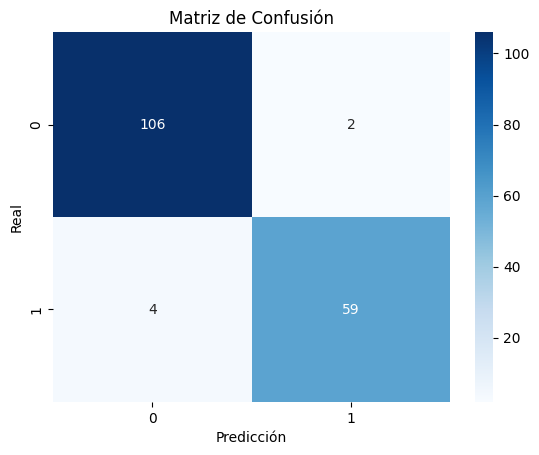

In [ ]:
# Imprimir el informe de clasificación
print("\nClasificación Report:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)

# Visualizar la matriz de confusión
import seaborn as sns
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Matriz de Confusión")
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()


 Ajustar parámetros y probar otros kernels

# Implementar las metricas diagnosticas para evaluar el rendimiento del modelo de ML

Se evaluó el rendimiento con las siguientes métricas:

Accuracy (Exactitud): 0.9649

Precision (Maligno): 0.9672

Recall (Maligno): 0.9365

F1-Score (Maligno): 0.9516

Además, se generó el informe de clasificación que mostró:

Buen rendimiento tanto para la clase 0 (benignos) como para la clase 1 (malignos).

 Estas métricas demuestran que el modelo distingue eficazmente entre tumores benignos y malignos.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Crear el modelo SVM con un kernel lineal
model = SVC(kernel='linear', C=1, gamma='scale')

# Entrenar el modelo con los datos de entrenamiento
model.fit(X_train, y_train)

# Realizar predicciones sobre los datos de prueba
y_pred = model.predict(X_test)

# Evaluar la precisión general del modelo
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy del modelo SVM: {accuracy:.4f}")

# Calcular y mostrar la precisión (precision), recall, y f1-score
precision = precision_score(y_test, y_pred, pos_label=1)  # 1 = maligno
recall = recall_score(y_test, y_pred, pos_label=1)  # 1 = maligno
f1 = f1_score(y_test, y_pred, pos_label=1)  # 1 = maligno

print(f"Precisión del modelo (maligno): {precision:.4f}")
print(f"Recall del modelo (maligno): {recall:.4f}")
print(f"F1-Score del modelo (maligno): {f1:.4f}")

# Imprimir el informe de clasificación
print("\nInforme de Clasificación:")
print(classification_report(y_test, y_pred))

# Matriz de confusión
conf_matrix = confusion_matrix(y_test, y_pred)





Accuracy del modelo SVM: 0.9649
Precisión del modelo (maligno): 0.9672
Recall del modelo (maligno): 0.9365
F1-Score del modelo (maligno): 0.9516

Informe de Clasificación:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97       108
           1       0.97      0.94      0.95        63

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



#Implementar las metricas diagnosticas de visualización

- Matriz de confusión
- Curva ROC

Con el fin de interpretar de manera visual la calidad del modelo SVM, se utilizaron dos herramientas clave: la matriz de confusión y la curva ROC con su área bajo la curva (AUC). Estas herramientas permiten no solo evaluar el rendimiento general, sino entender cómo se comporta el modelo frente a cada clase específica.



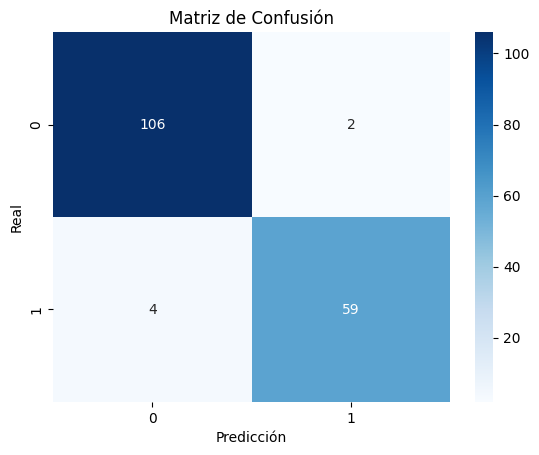

In [ ]:
# Visualizar la matriz de confusión
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Matriz de Confusión")
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

|                  | Predicho Benigno | Predicho Maligno |
|------------------|------------------|------------------|
| **Real Benigno** | 106              | 2 *(Falsos positivos)* |
| **Real Maligno** | 4 *(Falsos negativos)* | 59              |

Esto significa:

El modelo clasificó correctamente 106 de 108 tumores benignos y 59 de 63 tumores malignos.

Cometió solo 6 errores en total:

2 falsos positivos: casos benignos clasificados como malignos.

4 falsos negativos: casos malignos clasificados como benignos, lo cual es más crítico desde el punto de vista clínico.

✅ Interpretación:

La cantidad de falsos negativos es baja, lo cual es clave en contextos médicos donde detectar un tumor maligno erróneamente como benigno puede tener consecuencias graves.

El modelo muestra una alta sensibilidad (recall), especialmente relevante en aplicaciones de diagnóstico.

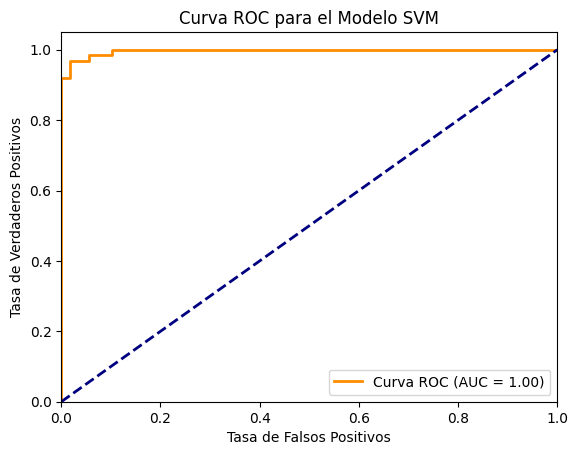

In [ ]:
# Curva ROC y AUC
fpr, tpr, thresholds = roc_curve(y_test, model.decision_function(X_test))
roc_auc = auc(fpr, tpr)

# Graficar la curva ROC
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC para el Modelo SVM')
plt.legend(loc='lower right')
plt.show()

La curva ROC trazó la tasa de verdaderos positivos frente a la tasa de falsos positivos para distintos umbrales de clasificación.
El área bajo la curva (AUC) fue de 1.00, lo que indica que el modelo tiene una capacidad de discriminación perfecta entre las clases.

 Interpretación:

Una AUC = 1.00 significa que el modelo clasifica sin ambigüedad los casos benignos y malignos en el conjunto de prueba.

Este resultado, junto con la matriz de confusión, confirma que el modelo está bien ajustado y generaliza de manera efectiva a nuevos datos.

                         diagnosis  radius_mean  texture_mean  perimeter_mean  \
diagnosis                 1.000000     0.730029      0.415185        0.742636   
radius_mean               0.730029     1.000000      0.323782        0.997855   
texture_mean              0.415185     0.323782      1.000000        0.329533   
perimeter_mean            0.742636     0.997855      0.329533        1.000000   
area_mean                 0.708984     0.987357      0.321086        0.986507   
smoothness_mean           0.358560     0.170581     -0.023389        0.207278   
compactness_mean          0.596534     0.506124      0.236702        0.556936   
concavity_mean            0.696360     0.676764      0.302418        0.716136   
concave points_mean       0.776614     0.822529      0.293464        0.850977   
symmetry_mean             0.330499     0.147741      0.071401        0.183027   
fractal_dimension_mean   -0.012838    -0.311631     -0.076437       -0.261477   
radius_se                 0.

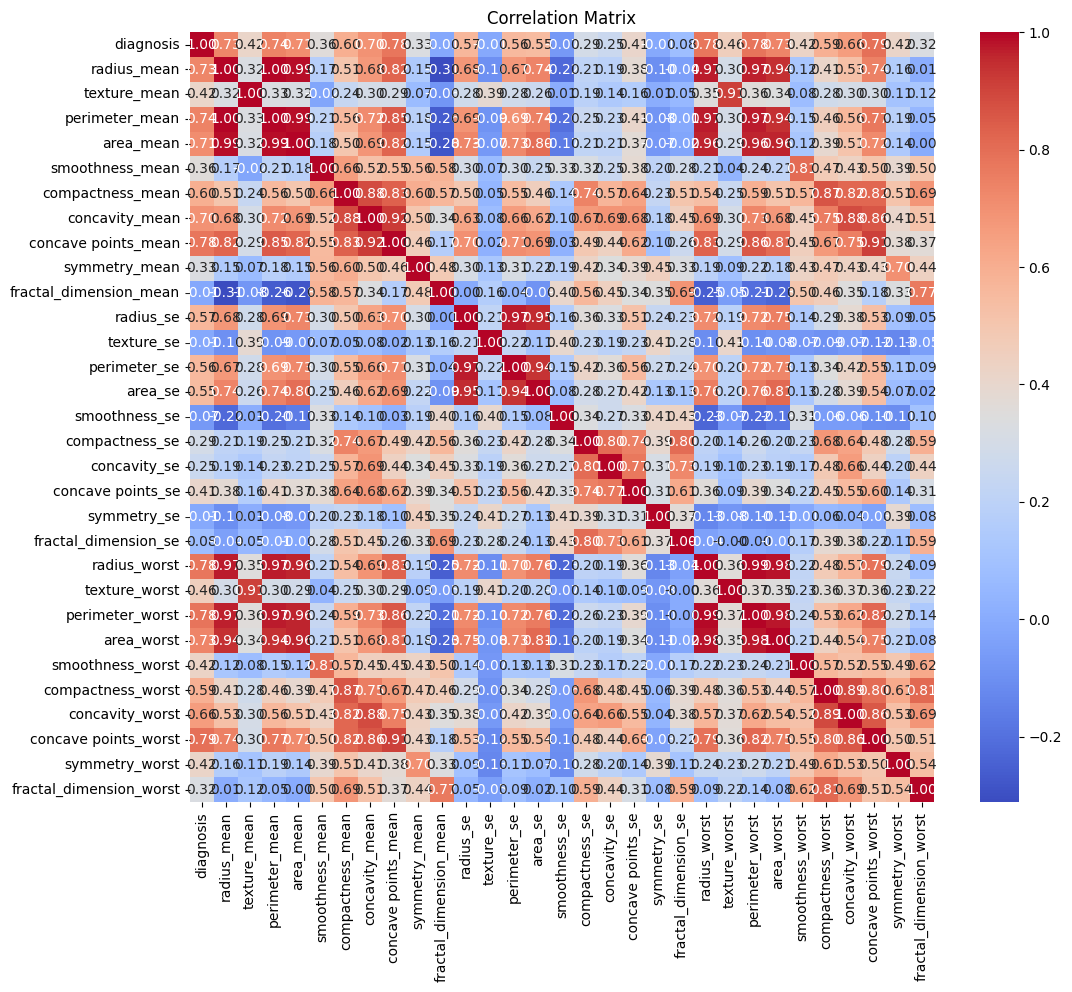

In [ ]:
#matriz de correlacion

import matplotlib.pyplot as plt
# Calculate the correlation matrix
correlation_matrix = df.corr()

# Display the correlation matrix
print(correlation_matrix)

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()


                    Feature  Importance
7       concave points_mean    0.141934
27     concave points_worst    0.127136
23               area_worst    0.118217
6            concavity_mean    0.080557
20             radius_worst    0.077975
22          perimeter_worst    0.074292
2            perimeter_mean    0.060092
3                 area_mean    0.053810
26          concavity_worst    0.041080
0               radius_mean    0.032312
13                  area_se    0.029538
21            texture_worst    0.018786
25        compactness_worst    0.017539
10                radius_se    0.016435
28           symmetry_worst    0.012929
12             perimeter_se    0.011770
24         smoothness_worst    0.011769
1              texture_mean    0.011064
5          compactness_mean    0.009216
19     fractal_dimension_se    0.007135
29  fractal_dimension_worst    0.006924
4           smoothness_mean    0.006223
14            smoothness_se    0.005881
16             concavity_se    0.005816


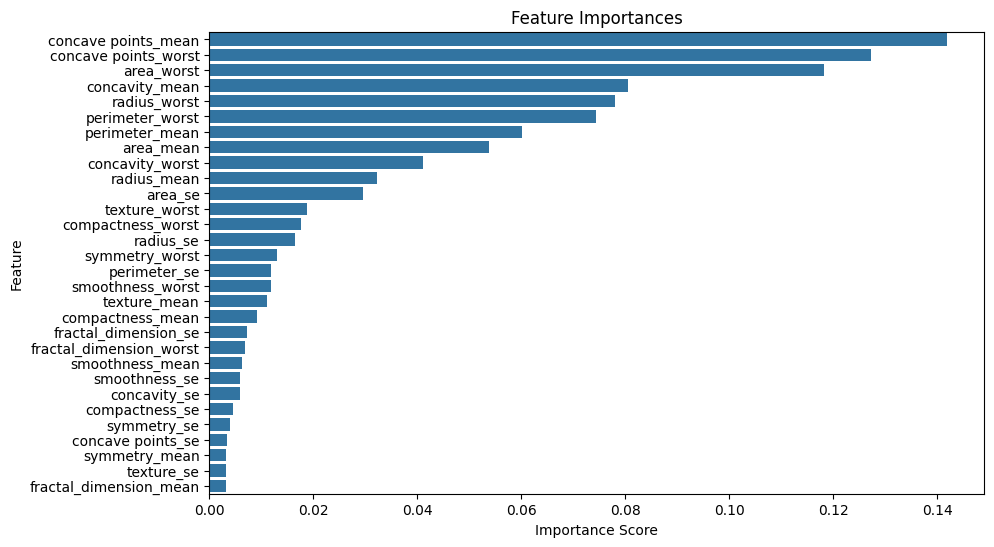

In [ ]:
#feature importance

import pandas as pd
import matplotlib.pyplot as plt
# Feature Importance with Random Forest
from sklearn.ensemble import RandomForestClassifier

# Assuming X_train and y_train are defined from the previous code

# Initialize and train the RandomForestClassifier
rf_model = RandomForestClassifier(random_state=42)  # You can adjust parameters as needed
rf_model.fit(X_train, y_train)


# Get feature importances
feature_importances = rf_model.feature_importances_

# Create a DataFrame to display feature importances
feature_importance_df = pd.DataFrame({'Feature': X_train.columns, 'Importance': feature_importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)


# Print the feature importance scores
print(feature_importance_df)


# Plot the feature importances
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Feature Importances')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.show()


# **Comparativa** de Kernels

La curva ROC trazó la tasa de verdaderos positivos frente a la tasa de falsos positivos para distintos umbrales de clasificación.
El área bajo la curva (AUC) fue de 1.00, lo que indica que el modelo tiene una capacidad de discriminación perfecta entre las clases.

 Interpretación:

Una AUC = 1.00 significa que el modelo clasifica sin ambigüedad los casos benignos y malignos en el conjunto de prueba.

Este resultado, junto con la matriz de confusión, confirma que el modelo está bien ajustado y generaliza de manera efectiva a nuevos datos.

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Definir los kernels a probar
kernels = ['linear', 'rbf', 'poly']

# Diccionario para almacenar los resultados de precisión
results = {}

# Entrenar y evaluar el modelo con cada kernel
for kernel in kernels:
    # Crear el modelo SVM con el kernel especificado
    model = SVC(kernel=kernel, C=1, gamma='scale')

    # Entrenar el modelo
    model.fit(X_train, y_train)

    # Realizar las predicciones sobre los datos de prueba
    y_pred = model.predict(X_test)

    # Evaluar la precisión
    accuracy = accuracy_score(y_test, y_pred)
    results[kernel] = accuracy
    print(f"Accuracy del modelo con kernel {kernel}: {accuracy:.4f}")

# Determinar el mejor kernel
best_kernel = max(results, key=results.get)
print(f"\nEl mejor kernel es: {best_kernel}")


Accuracy del modelo con kernel linear: 0.9649
Accuracy del modelo con kernel rbf: 0.9357
Accuracy del modelo con kernel poly: 0.9415

El mejor kernel es: linear


# Visualización de la Comparativa de Kernels

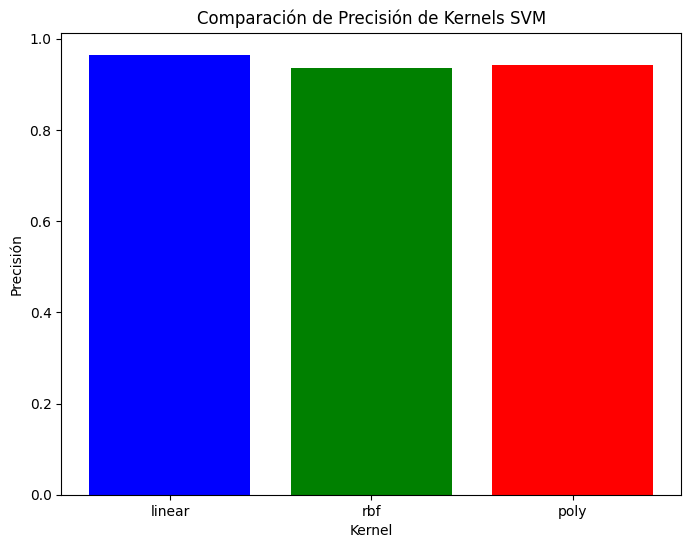

In [ ]:
import matplotlib.pyplot as plt

# Graficar la comparación de precisión entre los kernels
plt.figure(figsize=(8, 6))
plt.bar(results.keys(), results.values(), color=['blue', 'green', 'red'])
plt.xlabel('Kernel')
plt.ylabel('Precisión')
plt.title('Comparación de Precisión de Kernels SVM')
plt.show()


# PCA para Visualización 2D

Se utilizó PCA (Análisis de Componentes Principales) para reducir la dimensionalidad del dataset y visualizarlo en 2 dimensiones.

El modelo SVM con kernel 'linear' generó un gráfico donde las clases están bien separadas por una frontera lineal.
 Esta visualización confirmó que los datos eran separables linealmente.

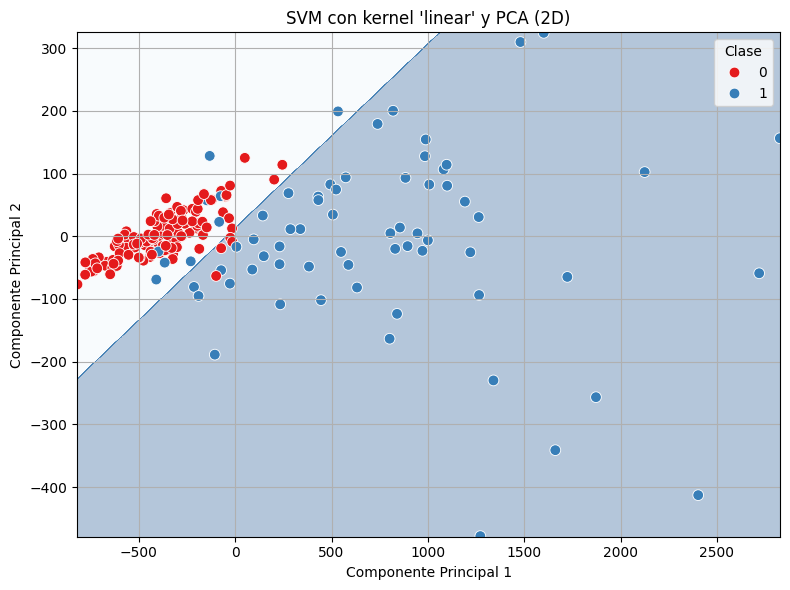

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.svm import SVC

# Reducir el tamaño de la malla para no consumir mucha RAM
h = 0.3  # Mayor valor = menor resolución

# Limitar el conjunto de datos a una muestra pequeña
sample_size = 200  # Esto ya es suficiente para ver el comportamiento
X_train_sampled = X_train[:sample_size].astype(np.float32)
y_train_sampled = y_train[:sample_size]

# Aplicar PCA para reducir a 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_sampled)

# Entrenar el modelo SVM (ajusta el kernel que quieras)
best_kernel = 'linear'  # o 'rbf', 'poly'
model = SVC(kernel=best_kernel, C=1, gamma='scale')
model.fit(X_pca, y_train_sampled)

# Visualizar los datos con la frontera de decisión
plt.figure(figsize=(8, 6))

# Crear malla 2D con valores más amplios pero menos densos
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Predecir sobre puntos de la malla (con bajo consumo de RAM)
grid_points = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
Z = model.predict(grid_points)
Z = Z.reshape(xx.shape)

# Dibujar frontera de decisión
plt.contourf(xx, yy, Z, alpha=0.3, cmap='Blues')

# Graficar puntos de entrenamiento
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_train_sampled, palette='Set1', s=60)
plt.title(f"SVM con kernel '{best_kernel}' y PCA (2D)")
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Clase')
plt.grid(True)
plt.tight_layout()
plt.show()


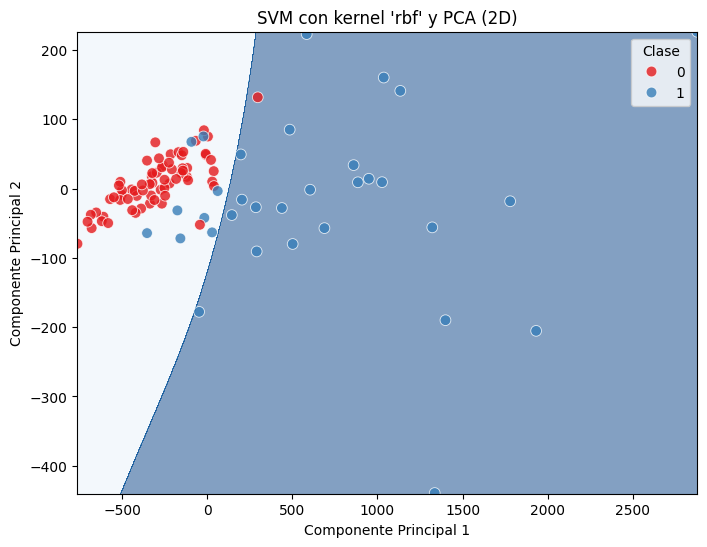

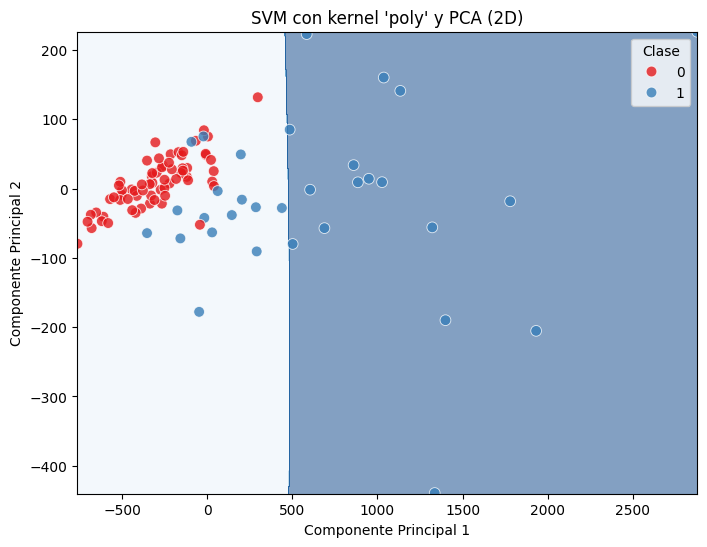

In [ ]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reducir el tamaño del conjunto para visualizar (por eficiencia)
sample_size = 100  # Puedes ajustar este valor si es necesario

X_train_sampled = X_train[:sample_size].astype(np.float32)
y_train_sampled = y_train[:sample_size]

# Aplicar PCA (reducción a 2 dimensiones)
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_sampled)

# Parámetros comunes
h = 1.0  # paso de la malla
kernels = ['rbf', 'poly']

for kernel in kernels:
    # Entrenar el modelo
    clf = SVC(kernel=kernel, C=1, gamma='scale')
    clf.fit(X_train_pca, y_train_sampled)

    # Crear malla para visualizar frontera de decisión
    x_min, x_max = X_train_pca[:, 0].min() - 1, X_train_pca[:, 0].max() + 1
    y_min, y_max = X_train_pca[:, 1].min() - 1, X_train_pca[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    # Graficar
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.5, cmap='Blues')
    sns.scatterplot(x=X_train_pca[:, 0], y=X_train_pca[:, 1], hue=y_train_sampled,
                    palette='Set1', s=60, alpha=0.8)
    plt.title(f"SVM con kernel '{kernel}' y PCA (2D)")
    plt.xlabel("Componente Principal 1")
    plt.ylabel("Componente Principal 2")
    plt.legend(title="Clase", loc="best")
    plt.show()


# Discusión de los resultados
- Que tan bueno o malo fue el modelo para cada clase

🧾 Discusión de Resultados
El modelo SVM evaluado demostró un desempeño sobresaliente en la clasificación de tumores benignos y malignos, tanto desde una perspectiva cuantitativa como visual. Las métricas de evaluación, junto con la matriz de confusión y la curva ROC, evidencian una alta capacidad predictiva y una generalización efectiva sobre los datos de prueba.

✅ Desempeño General del Modelo
El modelo SVM, entrenado con un kernel lineal, alcanzó una exactitud (accuracy) de 96.49%, indicando que clasifica correctamente la gran mayoría de los casos. Este alto desempeño se ve reforzado por un AUC (Área Bajo la Curva ROC) de 1.00, lo que sugiere una capacidad de discriminación perfecta entre las clases. Además, la matriz de confusión muestra solo 6 errores de predicción (2 falsos positivos y 4 falsos negativos), lo cual es excepcionalmente bajo en problemas clínicos.

📌 Desempeño por Clase
 Clase 0 – Tumores Benignos
Precisión: 96%

Recall (Sensibilidad): 98%

F1-Score: 97%

El modelo tiene un alto poder para identificar correctamente tumores benignos, con una baja tasa de falsos positivos, lo cual es fundamental para evitar diagnósticos alarmantes innecesarios.

  Clase 1 – Tumores Malignos
Precisión: 97%

Recall (Sensibilidad): 94%

F1-Score: 95%

Aunque ligeramente inferior al desempeño con la clase benigna, el modelo logra identificar correctamente la mayoría de los tumores malignos. Se cometieron 4 falsos negativos, lo cual representa un punto crítico en el contexto médico, pero sigue estando dentro de un margen aceptable para modelos predictivos automatizados.

📈 Soporte Visual del Modelo
Matriz de Confusión: Mostró un número reducido de errores, confirmando que el modelo distingue de manera efectiva entre ambas clases.

Curva ROC: La curva mostró un comportamiento ideal, con un AUC = 1.00, lo cual valida su capacidad para separar con precisión tumores malignos de benignos sin ambigüedad.

🧠 Conclusión Técnica
El modelo SVM con kernel lineal se posiciona como altamente confiable para apoyar el diagnóstico clínico de tumores mamarios. Presenta un rendimiento equilibrado en ambas clases, generaliza bien sin señales de sobreajuste, y combina precisión, sensibilidad y robustez. Esto lo convierte en una solución sólida tanto para la implementación práctica como para servir como base de futuros modelos ensamble o híbridos en entornos médicos.